In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.data import load_netset
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

In [2]:
print("Loading WikiSchools dataset...")
dataset = load_netset('wikischools')
print(f"Keys: {list(dataset.keys())}")

adj = dataset['adjacency']
print(f"Graph: {adj.shape[0]:,} nodes, {adj.nnz:,} edges")

adj.setdiag(0)
adj.eliminate_zeros()
adj = adj.tocsr()

node_names = dataset['names'] if 'names' in dataset else None
if node_names is not None:
    print(f"Sample nodes: {list(node_names[:5])}")

Loading WikiSchools dataset...
Unpacking archive...
Parsing files...
Done.
Keys: ['adjacency', 'biadjacency', 'labels', 'meta', 'names', 'names_col', 'names_labels']
Graph: 4,403 nodes, 112,834 edges
Sample nodes: [np.str_('Áedán mac Gabráin'), np.str_('Bede'), np.str_('Columba'), np.str_('Dál Riata'), np.str_('Great Britain')]


In [3]:
def conformal_quantile(scores, alpha):
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    if k > n:
        return np.inf
    return np.sort(scores)[k - 1]

def get_directed_node_features(adj, n_components=32):
    out_degrees = np.array(adj.sum(axis=1)).flatten()
    in_degrees = np.array(adj.sum(axis=0)).flatten()
    
    svd = SVD(n_components=n_components)
    source_emb = svd.fit_transform(adj)
    target_emb = svd.embedding_col_
    
    return out_degrees, in_degrees, source_emb, target_emb

def compute_pair_features(pairs, out_deg, in_deg, src_emb, tgt_emb):
    u, v = pairs[:, 0], pairs[:, 1]
    
    vec_u_src, vec_v_tgt = src_emb[u], tgt_emb[v]
    norm_u_src = np.linalg.norm(vec_u_src, axis=1)
    norm_v_tgt = np.linalg.norm(vec_v_tgt, axis=1)
    norm_u_src[norm_u_src == 0] = 1e-9
    norm_v_tgt[norm_v_tgt == 0] = 1e-9
    sim_fwd = np.sum(vec_u_src * vec_v_tgt, axis=1) / (norm_u_src * norm_v_tgt)
    
    vec_v_src, vec_u_tgt = src_emb[v], tgt_emb[u]
    norm_v_src = np.linalg.norm(vec_v_src, axis=1)
    norm_u_tgt = np.linalg.norm(vec_u_tgt, axis=1)
    norm_v_src[norm_v_src == 0] = 1e-9
    norm_u_tgt[norm_u_tgt == 0] = 1e-9
    sim_rev = np.sum(vec_v_src * vec_u_tgt, axis=1) / (norm_v_src * norm_u_tgt)
    
    return np.column_stack([out_deg[u], in_deg[v], in_deg[u], out_deg[v], sim_fwd, sim_rev])

In [4]:
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_pipeline(adj, name="dataset", alpha=0.10, n_runs=5, n_components=32, msg_ratio=0.7, node_names=None):
    print(f"\n{'='*60}")
    print(f"Pipeline: {name.upper()} | {n_runs} runs | alpha={alpha}")
    print(f"{'='*60}")
    
    n_nodes = adj.shape[0]
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    all_edges_set = set(zip(rows, cols))
    print(f"Graph: {n_nodes:,} nodes, {len(all_edges):,} edges")
    
    run_results = []
    last_run = {}
    
    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        edges = all_edges.copy()
        rng.shuffle(edges)
        
        n = len(edges)
        n_cal, n_test = int(n * 0.1), int(n * 0.1)
        E_cal, E_test = edges[:n_cal], edges[n_cal:n_cal+n_test]
        E_train = edges[n_cal+n_test:]
        
        n_msg = int(len(E_train) * msg_ratio)
        idx = rng.permutation(len(E_train))
        E_msg, E_sup = E_train[idx[:n_msg]], E_train[idx[n_msg:]]
        
        adj_msg = sp.csr_matrix((np.ones(len(E_msg)), (E_msg[:,0], E_msg[:,1])), shape=(n_nodes, n_nodes))
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()
        
        out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_msg, n_components)
        
        def make_dataset(pos_edges):
            neg = set()
            while len(neg) < len(pos_edges):
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in all_edges_set:
                    neg.add((u, v))
            neg = np.array(list(neg))
            X = np.vstack([compute_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb),
                          compute_pair_features(neg, out_deg, in_deg, src_emb, tgt_emb)])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg))])
            return X, y, np.vstack([pos_edges, neg])
        
        X_train, y_train, _ = make_dataset(E_sup)
        X_cal, y_cal, _ = make_dataset(E_cal)
        X_test, y_test, test_pairs = make_dataset(E_test)
        
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)
        
        p_cal, p_test = clf.predict_proba(X_cal)[:,1], clf.predict_proba(X_test)[:,1]
        
        q1 = conformal_quantile(1 - p_cal[y_cal == 1], alpha)
        q0 = conformal_quantile(p_cal[y_cal == 0], alpha)
        t_lower, t_upper = q0, 1 - q1
        
        sets = []
        for p in p_test:
            s = set()
            if p <= t_lower: s.add(0)
            if p >= t_upper: s.add(1)
            if not s: s = {0, 1}
            sets.append(s)
        
        coverage = np.mean([y in s for y, s in zip(y_test, sets)])
        abstention = np.mean([len(s) > 1 for s in sets])
        
        decided_idx = [i for i, s in enumerate(sets) if len(s) == 1]
        f1_dec = 0.0
        if decided_idx:
            _, _, f1_dec, _ = precision_recall_fscore_support(
                y_test[decided_idx], [list(sets[i])[0] for i in decided_idx], average='binary', zero_division=0)
        
        auc = roc_auc_score(y_test, p_test)
        y_pred = (p_test >= 0.5).astype(int)
        _, _, base_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
        
        run_results.append({"AUC": auc, "Base F1": base_f1, "Coverage": coverage, 
                           "Abstention": abstention, "Decided F1": f1_dec})
        
        last_run = {'clf': clf, 'y_test': y_test, 'p_test': p_test, 'y_pred': y_pred,
                   'X_test': X_test, 'test_pairs': test_pairs, 't_lower': t_lower, 
                   't_upper': t_upper, 'sets': sets, 'auc': auc}
        
        print(f"Run {seed+1}: AUC={auc:.4f} | Cov={coverage:.4f} | Abs={abstention:.4f}")
    
    df = pd.DataFrame(run_results)
    print(f"\n--- Results ({name}) ---")
    for col in df.columns:
        print(f"{col}: {df[col].mean():.4f} +/- {df[col].std():.4f}")
    
    # Feature Importance
    print(f"\n--- Feature Importance ---")
    fi = last_run['clf'].feature_importances_
    for i in np.argsort(fi)[::-1]:
        print(f"{FEATURE_NAMES[i]}: {fi[i]:.4f}")
    
    # Error Analysis
    y_test, p_test, y_pred = last_run['y_test'], last_run['p_test'], last_run['y_pred']
    test_pairs = last_run['test_pairs']
    
    fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]
    fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]
    fp_sorted = fp_idx[np.argsort(p_test[fp_idx])[::-1]] if len(fp_idx) > 0 else []
    fn_sorted = fn_idx[np.argsort(p_test[fn_idx])] if len(fn_idx) > 0 else []
    
    print(f"\n--- Error Analysis ---")
    print(f"False Positives: {len(fp_idx):,} | False Negatives: {len(fn_idx):,}")
    
    print(f"\nTop 10 False Positives:")
    for rank, idx in enumerate(fp_sorted[:10], 1):
        pair = test_pairs[idx]
        nm = f"{node_names[pair[0]]} -> {node_names[pair[1]]}" if node_names is not None else f"{pair[0]}->{pair[1]}"
        print(f"{rank}. {nm} (p={p_test[idx]:.4f})")
    
    print(f"\nTop 10 False Negatives:")
    for rank, idx in enumerate(fn_sorted[:10], 1):
        pair = test_pairs[idx]
        nm = f"{node_names[pair[0]]} -> {node_names[pair[1]]}" if node_names is not None else f"{pair[0]}->{pair[1]}"
        print(f"{rank}. {nm} (p={p_test[idx]:.4f})")
    
    # Plots
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    
    fpr, tpr, _ = roc_curve(y_test, p_test)
    axes[0,0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={last_run["auc"]:.3f}')
    axes[0,0].plot([0,1], [0,1], 'k--')
    axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')
    axes[0,0].set_title('ROC Curve'); axes[0,0].legend()
    
    axes[0,1].hist(p_test[y_test==0], bins=30, alpha=0.5, color='red', label='Non-edge')
    axes[0,1].hist(p_test[y_test==1], bins=30, alpha=0.5, color='blue', label='Edge')
    axes[0,1].axvline(last_run['t_lower'], color='red', ls='--', label=f't_low={last_run["t_lower"]:.2f}')
    axes[0,1].axvline(last_run['t_upper'], color='blue', ls='--', label=f't_up={last_run["t_upper"]:.2f}')
    axes[0,1].set_title('Probability Distribution'); axes[0,1].legend()
    
    sizes = [len(s) for s in last_run['sets']]
    axes[0,2].bar(['Decided', 'Abstain'], [sizes.count(1), sizes.count(2)], color=['green', 'orange'])
    axes[0,2].set_title('Prediction Sets')
    
    sorted_idx = np.argsort(fi)[::-1]
    axes[1,0].barh([FEATURE_NAMES[i] for i in sorted_idx[::-1]], [fi[i] for i in sorted_idx[::-1]])
    axes[1,0].set_title('Feature Importance')
    
    if len(fp_idx) > 0: axes[1,1].hist(p_test[fp_idx], bins=20, alpha=0.5, color='orange', label=f'FP (n={len(fp_idx)})')
    if len(fn_idx) > 0: axes[1,1].hist(p_test[fn_idx], bins=20, alpha=0.5, color='purple', label=f'FN (n={len(fn_idx)})')
    axes[1,1].axvline(0.5, color='k', ls='--')
    axes[1,1].set_title('Error Distribution'); axes[1,1].legend()
    
    axes[1,2].bar(['FP', 'FN'], [len(fp_idx), len(fn_idx)], color=['orange', 'purple'])
    axes[1,2].set_title('Error Counts')
    
    plt.tight_layout()
    plt.show()
    
    return df, {'feature_importance': dict(zip(FEATURE_NAMES, fi.tolist())),
                'n_fp': len(fp_idx), 'n_fn': len(fn_idx)}


Pipeline: WIKISCHOOLS | 10 runs | alpha=0.1
Graph: 4,403 nodes, 112,728 edges
Run 1: AUC=0.9325 | Cov=0.9019 | Abs=0.0992
Run 2: AUC=0.9367 | Cov=0.9018 | Abs=0.0849
Run 3: AUC=0.9345 | Cov=0.8987 | Abs=0.0869
Run 4: AUC=0.9359 | Cov=0.9020 | Abs=0.0847
Run 5: AUC=0.9353 | Cov=0.9032 | Abs=0.0887
Run 6: AUC=0.9305 | Cov=0.8966 | Abs=0.0903
Run 7: AUC=0.9348 | Cov=0.9039 | Abs=0.0912
Run 8: AUC=0.9363 | Cov=0.9023 | Abs=0.0908
Run 9: AUC=0.9340 | Cov=0.9013 | Abs=0.0888
Run 10: AUC=0.9320 | Cov=0.9004 | Abs=0.0886

--- Results (WikiSchools) ---
AUC: 0.9343 +/- 0.0020
Base F1: 0.8608 +/- 0.0025
Coverage: 0.9012 +/- 0.0022
Abstention: 0.0894 +/- 0.0041
Decided F1: 0.8920 +/- 0.0025

--- Feature Importance ---
in_deg_v: 0.6283
sim_forward: 0.2265
sim_reverse: 0.0950
out_deg_u: 0.0470
out_deg_v: 0.0018
in_deg_u: 0.0014

--- Error Analysis ---
False Positives: 1,461 | False Negatives: 1,707

Top 10 False Positives:
1. Selenium -> Mineral (p=0.9837)
2. Scandium -> Lead (p=0.9832)
3. Fennel -

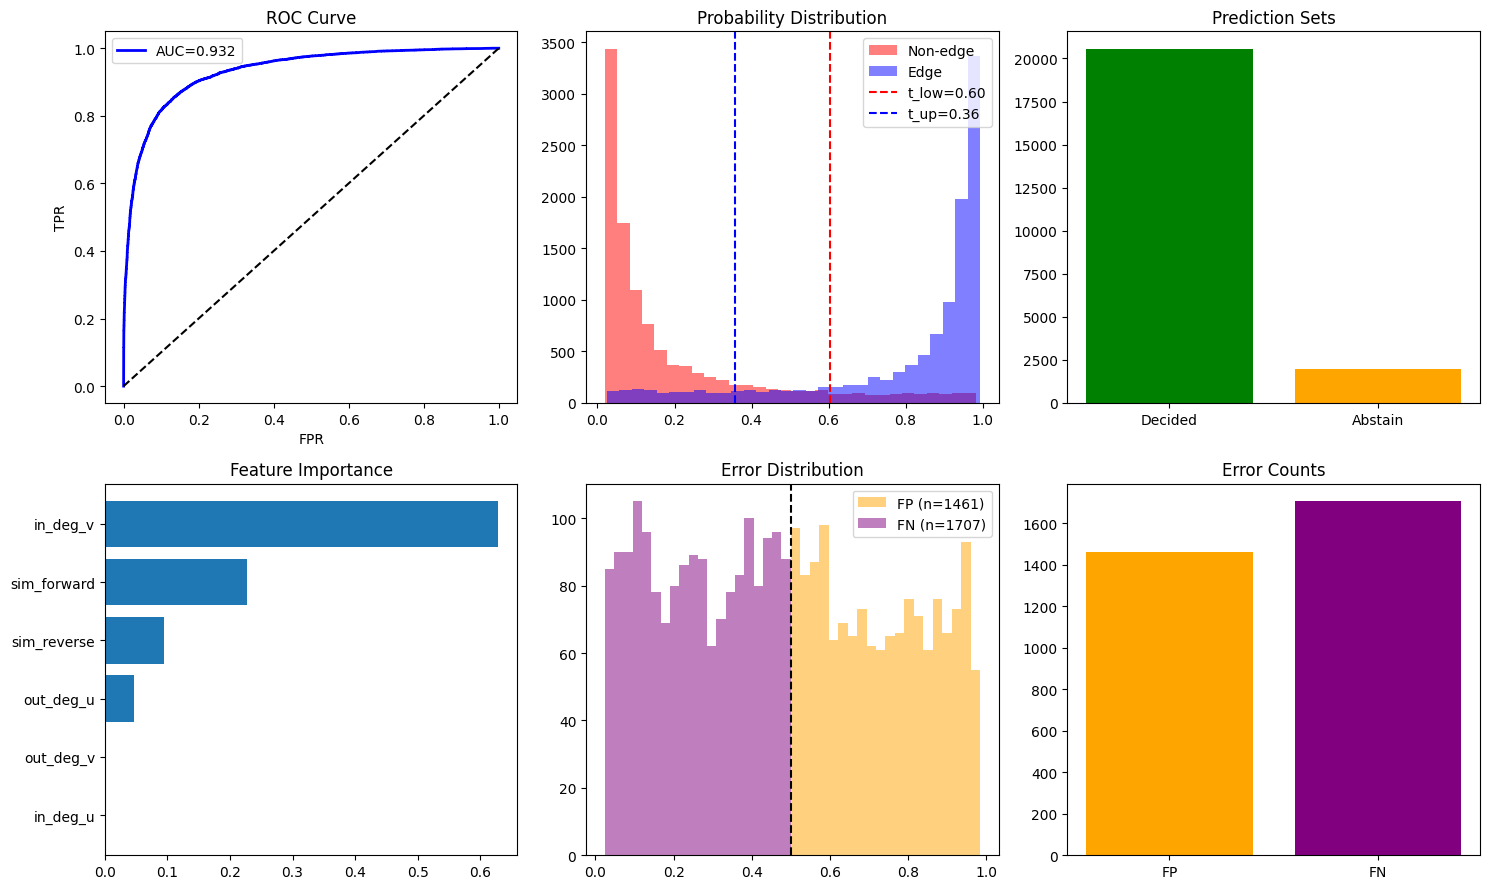

In [5]:
results, analysis = run_pipeline(
    adj=adj,
    name="WikiSchools",
    alpha=0.10,
    n_runs=10,
    n_components=32,
    node_names=node_names
)

In [6]:
print("Results Summary:")
display(results)
print(f"\nAnalysis: {analysis}")

Results Summary:


,AUC,Base F1,Coverage,Abstention,Decided F1
0,0.932504,0.859160,0.901925,0.099184,0.891994
1,0.936670,0.863359,0.901792,0.084856,0.892576
2,0.934524,0.860031,0.898687,0.086941,0.889587
3,0.935944,0.862860,0.901969,0.084723,0.893699
4,0.935267,0.862169,0.903167,0.088715,0.894240
5,0.930489,0.855890,0.896602,0.090312,0.886409
6,0.934792,0.861852,0.903877,0.091244,0.894370
7,0.936326,0.862098,0.902324,0.090800,0.893386
8,0.933987,0.862530,0.901260,0.088848,0.892785
9,0.932007,0.857924,0.900417,0.088582,0.890579



Analysis: {'feature_importance': {'out_deg_u': 0.04699141985443073, 'in_deg_v': 0.6282729164840571, 'in_deg_u': 0.001398096231086165, 'out_deg_v': 0.0018113684358486625, 'sim_forward': 0.2265326816459264, 'sim_reverse': 0.09499351734865098}, 'n_fp': 1461, 'n_fn': 1707}
